1. 正在自動尋找資料集路徑...
✅ 找到資料集了！實際路徑為：/kaggle/input/competitions/human-protein-atlas-image-classification
2. 正在讀取龐大的 CSV 標籤檔案...
   -> 成功取得第一張圖片的 ID: 00070df0-bbc3-11e8-b2bc-ac1f6b6435d0
3. 開始讀取並繪製四個螢光通道的影像...
4. 繪製完成！


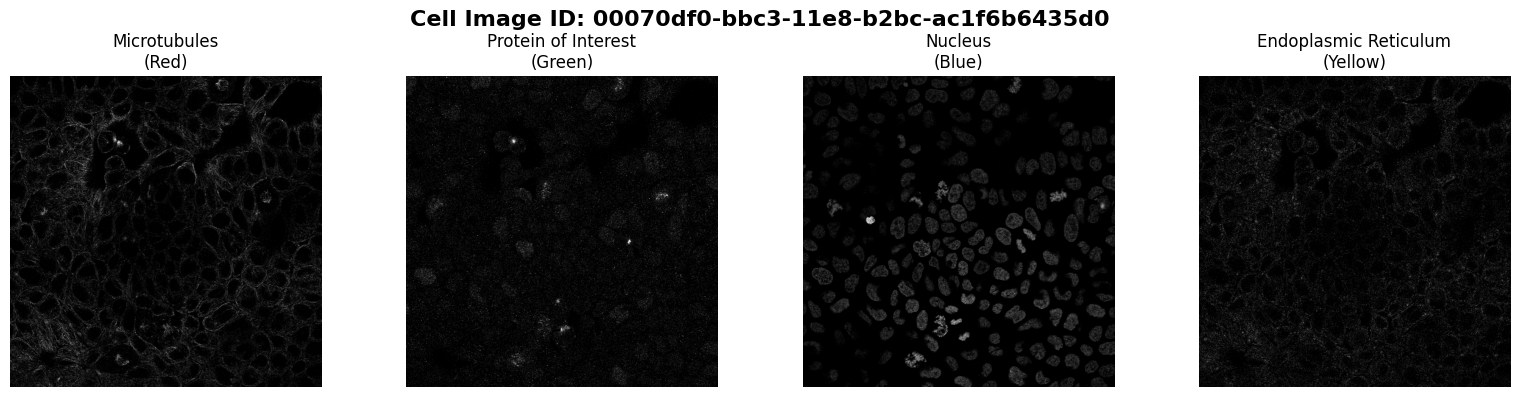

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import cv2

print("1. 正在自動尋找資料集路徑...")
# 讓電腦自己去 /kaggle/input 目錄下翻找 train.csv
DATA_DIR = ""
for root, dirs, files in os.walk('/kaggle/input'):
    if 'train.csv' in files:
        DATA_DIR = root
        break

if not DATA_DIR:
    print("❌ 找不到 train.csv！請確認右側面板的 'Data' 區塊是否有加入比賽資料。")
else:
    print(f"✅ 找到資料集了！實際路徑為：{DATA_DIR}")
    TRAIN_DIR = os.path.join(DATA_DIR, 'train')

    print("2. 正在讀取龐大的 CSV 標籤檔案...")
    df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
    sample_id = df['Id'].iloc[0] 
    print(f"   -> 成功取得第一張圖片的 ID: {sample_id}")

    colors = ['red', 'green', 'blue', 'yellow']
    titles = [
        'Microtubules\n(Red)', 
        'Protein of Interest\n(Green)', 
        'Nucleus\n(Blue)', 
        'Endoplasmic Reticulum\n(Yellow)'
    ]

    print("3. 開始讀取並繪製四個螢光通道的影像...")
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for i, color in enumerate(colors):
        img_path = os.path.join(TRAIN_DIR, f"{sample_id}_{color}.png")
        
        if not os.path.exists(img_path):
            print(f"   [警告] 找不到圖片: {img_path}")
            continue
            
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(titles[i])
        axes[i].axis('off')

    print("4. 繪製完成！")
    plt.suptitle(f"Cell Image ID: {sample_id}", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

開始疊加彩色影像...


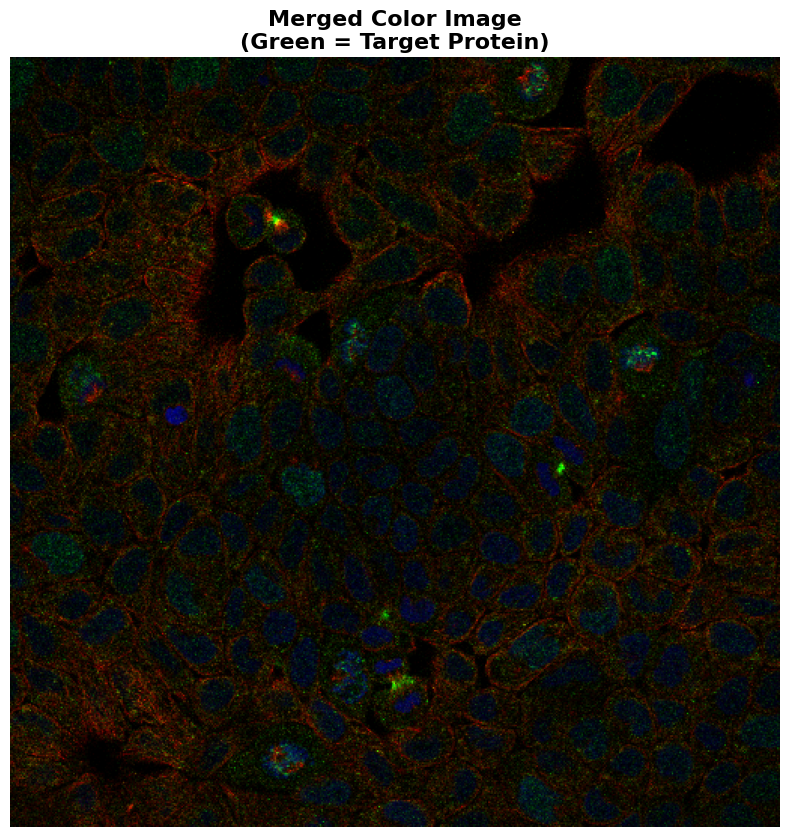

In [6]:
import numpy as np

print("開始疊加彩色影像...")

# 1. 再次從硬碟讀取這四張灰階圖片
img_red = cv2.imread(os.path.join(TRAIN_DIR, f"{sample_id}_red.png"), cv2.IMREAD_GRAYSCALE)
img_green = cv2.imread(os.path.join(TRAIN_DIR, f"{sample_id}_green.png"), cv2.IMREAD_GRAYSCALE)
img_blue = cv2.imread(os.path.join(TRAIN_DIR, f"{sample_id}_blue.png"), cv2.IMREAD_GRAYSCALE)
img_yellow = cv2.imread(os.path.join(TRAIN_DIR, f"{sample_id}_yellow.png"), cv2.IMREAD_GRAYSCALE)

# 2. 準備一張全黑的彩色畫布 (高, 寬, 3個RGB通道)
h, w = img_red.shape
merged_image = np.zeros((h, w, 3), dtype=np.uint8)

# 3. 把顏色填進對應的 RGB 通道
# 使用 cv2.add 可以確保兩個數字相加如果超過 255 (最亮)，就停在 255，不會發生「破圖」的數學溢位

# Red 通道：微管(紅) + 內質網(黃)
merged_image[:, :, 0] = cv2.add(img_red, img_yellow)    

# Green 通道：目標蛋白質(綠) + 內質網(黃)
merged_image[:, :, 1] = cv2.add(img_green, img_yellow)  

# Blue 通道：細胞核(藍)
merged_image[:, :, 2] = img_blue                        

# 4. 把合成好的彩色影像畫出來！
plt.figure(figsize=(10, 10))
plt.imshow(merged_image)
plt.title("Merged Color Image\n(Green = Target Protein)", fontsize=16, fontweight='bold')
plt.axis('off')
plt.show()

In [11]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import cv2

print("--- 第一步：重新建立與編譯模型 ---")
# 建立 CNN 模型 (我們之前設計的 256x256x4 顯微鏡架構)
model_hpa = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 4)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(28, activation='sigmoid') # 28 種胞器位置
])

# 這是你剛剛少掉的最關鍵一步：編譯模型！
model_hpa.compile(
    optimizer='adam',
    loss='binary_crossentropy', 
    metrics=['accuracy']
)
print("模型建立與編譯完成！")


print("--- 第二步：準備資料輸送帶 ---")
# 自動尋找資料集路徑
DATA_DIR = ""
for root, dirs, files in os.walk('/kaggle/input'):
    if 'train.csv' in files:
        DATA_DIR = root
        break
TRAIN_DIR = os.path.join(DATA_DIR, 'train')

# 讀取 CSV 並取前 500 張圖片做示範
df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
sample_df = df.head(500)
image_ids = sample_df['Id'].values

# 轉換標籤為 28 維陣列 (Multi-hot Encoding)
def parse_labels(label_str):
    labels = np.zeros(28)
    for l in str(label_str).split():
        labels[int(l)] = 1
    return labels
labels = np.array([parse_labels(l) for l in sample_df['Target']])

# 讀取圖片並組合成 4 通道張量的函數
def load_image_and_label(image_id, label):
    image_id = image_id.decode('utf-8')
    channels = []
    for color in ['red', 'green', 'blue', 'yellow']:
        img_path = os.path.join(TRAIN_DIR, f"{image_id}_{color}.png")
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (256, 256)) # 縮小圖片加速訓練
        channels.append(img)
    img_tensor = np.stack(channels, axis=-1)
    img_tensor = img_tensor / 255.0 
    return img_tensor.astype(np.float32), label.astype(np.float32)

# 包裝給 TensorFlow Dataset 使用
def tf_load_image(image_id, label):
    img, lbl = tf.numpy_function(func=load_image_and_label, inp=[image_id, label], Tout=[tf.float32, tf.float32])
    img.set_shape((256, 256, 4))
    lbl.set_shape((28,))
    return img, lbl

# 建立自動化輸送帶
dataset = tf.data.Dataset.from_tensor_slices((image_ids, labels))
dataset = dataset.map(tf_load_image, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.batch(16)
dataset = dataset.prefetch(tf.data.AUTOTUNE)
# 建立一個權重字典
# 假設 0 是核質 (權重正常)，16 是分裂橋 (權重放大 50 倍)
# (實務上會寫一個迴圈根據樣本數自動計算，這裡我們手動示範)
custom_weights = {i: 1.0 for i in range(28)} 
custom_weights[16] = 50.0  # 特別關照 16 號胞器

# 在訓練時加入 class_weight 參數
history = model_hpa.fit(
    dataset, 
    epochs=5,
    class_weight=custom_weights # 啟動不平衡懲罰機制
)

print("--- 第三步：開始真實訓練！(請觀察 Loss 數值變化) ---")
# 正式開始訓練 5 個 Epoch
history = model_hpa.fit(dataset, epochs=5)

print("訓練完成！")

--- 第一步：重新建立與編譯模型 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


模型建立與編譯完成！
--- 第二步：準備資料輸送帶 ---
Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.1835 - loss: 0.3767
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.2178 - loss: 0.2467
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.2437 - loss: 0.2498
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.3567 - loss: 0.2070
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.4174 - loss: 0.1640
--- 第三步：開始真實訓練！(請觀察 Loss 數值變化) ---
Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.4796 - loss: 0.1291
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.5646 - loss: 0.0988
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.7132 - loss: 0.0686
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.7426 - loss: 0.0501
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.7224 - loss: 0.0339
訓練完成！


準備對答案！正在載入 28 種細胞胞器名稱字典...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


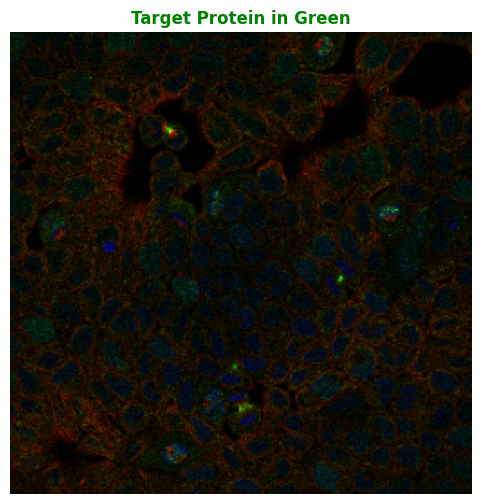


========== 考試結果對比 ==========
🎯 真實的蛋白質位置 (Ground Truth):
   - Nucleoplasm (核質)
   - Cytokinetic bridge (細胞質分裂橋)

🤖 AI 模型的預測 (Predictions):
   - Nucleoplasm (核質) (機率: 92.6%)
   - Cytokinetic bridge (細胞質分裂橋) (機率: 30.8%)


In [18]:
import matplotlib.pyplot as plt

print("準備對答案！正在載入 28 種細胞胞器名稱字典...")
# 這是 HPA 官方定義的 28 種細胞位置名稱
label_names = {
    0: "Nucleoplasm (核質)", 1: "Nuclear membrane (核膜)", 2: "Nucleoli (核仁)",
    3: "Nucleoli fibrillar center (核仁纖維中心)", 4: "Nuclear speckles (核斑)",
    5: "Nuclear bodies (核體)", 6: "Endoplasmic reticulum (內質網)", 7: "Golgi apparatus (高基氏體)",
    8: "Peroxisomes (過氧化體)", 9: "Endosomes (內體)", 10: "Lysosomes (溶體)",
    11: "Intermediate filaments (中間絲)", 12: "Actin filaments (肌動蛋白絲)",
    13: "Focal adhesion sites (黏著斑)", 14: "Microtubules (微管)",
    15: "Microtubule ends (微管端)", 16: "Cytokinetic bridge (細胞質分裂橋)",
    17: "Mitotic spindle (有絲分裂紡錘體)", 18: "Microtubule organizing center (微管組織中心)",
    19: "Centrosome (中心體)", 20: "Lipid droplets (脂滴)", 21: "Plasma membrane (細胞膜)",
    22: "Cell junctions (細胞連接)", 23: "Mitochondria (粒線體)",
    24: "Aggresome (聚集體)", 25: "Cytosol (細胞質)", 26: "Cytoplasmic bodies (細胞質體)",
    27: "Rods & rings (桿狀與環狀結構)"
}

# 1. 從輸送帶 (dataset) 中隨機拿一個批次 (Batch) 的資料
for images, true_labels in dataset.take(1):
    # 我們只取這個批次裡面的「第一張」圖片來考試
    test_image = images[0]
    test_true_label = true_labels[0]
    break

# 2. 讓模型進行預測
# 注意：predict 預設接收一整批圖片，所以我們要用 tf.expand_dims 把它包裝成 (1, 256, 256, 4)
predictions = model_hpa.predict(tf.expand_dims(test_image, axis=0))
pred_probs = predictions[0] # 取得這張圖對應的 28 個機率值

# 3. 翻譯答案
# 找出真實標籤中標記為 1 的位置
true_locations = [label_names[i] for i, val in enumerate(test_true_label) if val == 1.0]

# 找出模型預測機率 > 0.5 的位置
threshold = 0.3
pred_locations = [f"{label_names[i]} (機率: {pred_probs[i]:.1%})" 
                  for i, prob in enumerate(pred_probs) if prob > threshold]

if not pred_locations:
    pred_locations = ["模型認為沒有明顯的特徵 (所有機率都 < 50%)"]

# 4. 把圖片轉回 RGB 彩色並畫出來，讓你用肉眼當評審
img_np = (test_image.numpy() * 255).astype(np.uint8)
rgb_img = np.zeros((256, 256, 3), dtype=np.uint8)
rgb_img[:, :, 0] = cv2.add(img_np[:,:,0], img_np[:,:,3]) # R = 微管(紅) + 內質網(黃)
rgb_img[:, :, 1] = cv2.add(img_np[:,:,1], img_np[:,:,3]) # G = 目標蛋白質(綠) + 內質網(黃)
rgb_img[:, :, 2] = img_np[:,:,2]                         # B = 細胞核(藍)

plt.figure(figsize=(6, 6))
plt.imshow(rgb_img)
plt.title("Target Protein in Green", color='green', fontweight='bold')
plt.axis('off')
plt.show()

# 5. 印出對比成績單
print("\n========== 考試結果對比 ==========")
print("🎯 真實的蛋白質位置 (Ground Truth):")
for loc in true_locations:
    print(f"   - {loc}")
    
print("\n🤖 AI 模型的預測 (Predictions):")
for loc in pred_locations:
    print(f"   - {loc}")
print("==================================")

In [17]:
print("\n--- 🕵️‍♂️ 深入黑盒子 ---")
print(f"Cytokinetic bridge 的實際預測機率為: {pred_probs[16]:.2%}")


--- 🕵️‍♂️ 深入黑盒子 ---
Cytokinetic bridge 的實際預測機率為: 30.79%
